# Aaron's contribution to the project
So, I'm interested in the observations that we've got. It sounds like, with regards to lots of ocean observations, there aren't enough of them.

We've got a handful of data that are showing up [in CIOOS](https://explore.cioos.ca/?lat=44.354407178115565&lon=-66.14962611228577&zoom=9.234117507629128&lang=en):

| Source | Years | Link |
| ------ | ----- | ---- |
| BIO/DFO CTDs | 2009 | [ceotr.ca ERDDAP](https://data.ceotr.ca/erddap/tabledap/bio_ctd_public_bio_ctd_data.html) |
| Digby water quality data (CMAR) | 2016-2025 | [cioos.ca ERDDAP](https://cioosatlantic.ca/erddap/tabledap/wpsu-7fer.html) |
| Fisheries and Oceans Canada Coastal rosette casts | 2009 | [cioos.ca ERDDAP](https://cioosatlantic.ca/erddap/tabledap/bio_historical_coastal_ctd.html) |
| Fisheries and Oceans Canada Moored timeseries | 1994, 2013 | [cioos.ca ERDDAP](https://cioosatlantic.ca/erddap/tabledap/bio_historical_coastal_moored_ctd.html) |
| Ye olde DFO/MEDS buoy data | 1977 - 1979 | TBD - download failed (must be requested) |
| Canadian Atlantic Shelf Temperature-Salinity (CASTS) | 1912-2024 | [FRDR](https://www.frdr-dfdr.ca/repo/dataset/3b8cc476-2621-4dae-b506-08b56f627e0a) (must be requested) |

My main objectives are:
1. How much of these observations are able to be downloaded or opened
2. Intercompare the readings and locations
3. Look into creating a climatology or reverse forecasting to get the CMAR data to overlap better with FVCOM (circulation data that went from 2017-2018)
4. Compare these observations and forecasts to what the CANESM2 model has suggested for those regions

We're probably gonna need xarray, netCDF4, pyarrow, polars/pandas for loading data. I like Bokeh for visualizations, so we'll want that as well.

TODO: Create a `requirements.txt` for installation purposes.

In [1]:
import xarray as xr
import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

The general consensus is that we shouldn't be putting gigs of data on a Google Drive or Github. So the only data that we'll be pushing here should be small in size. Furthermore, none of these observations are gridded, so they don't need to be netCDF files. As such, it seems like the group is most comfortable with CSVs so I'll use that.

For these observations, this means that the CMAR and CASTS datasets won't be accessible. Within this repository (`/data`):
* bio_historical_coastal_ctd - FOCC rosettes.
* bio_historical_coastal_moored_ctd - FOCC moorings.
* cde_download.../bio_ctd_public_bio_ctd... - BIO/DFO data.

There are two more:
* FRDR_dataset_734_download_182_202608251807/* - these are the CASTS... well... casts.
* wpsu-7fer... - this is the CMAR data.

## FOCC rosettes

In [2]:
focc_ros = pd.read_csv(Path("../../data/bio_historical_coastal_ctd_4d4e_20de_74ab.csv"))
# focc_ros, focc_ros_units = focc_ros.drop(1)
focc_ros_units = focc_ros.iloc[0]
focc_ros = focc_ros.drop(0).reset_index(drop=True)
print(len(focc_ros))
print(focc_ros.head())

1222
   project platform_name  platform_id chief_scientist  \
0      NaN     M. Perley    9656151.0    Ryan Stanley   
1      NaN     M. Perley    9656151.0    Ryan Stanley   
2      NaN     M. Perley    9656151.0    Ryan Stanley   
3      NaN     M. Perley    9656151.0    Ryan Stanley   
4      NaN     M. Perley    9656151.0    Ryan Stanley   

                         cruise_name cruise_number geographic_area  station  \
0  Eastern Shore Water, St Anns Bank    PER2023767  ScotiaFundy-6       NaN   
1  Eastern Shore Water, St Anns Bank    PER2023767  ScotiaFundy-6       NaN   
2  Eastern Shore Water, St Anns Bank    PER2023767  ScotiaFundy-6       NaN   
3  Eastern Shore Water, St Anns Bank    PER2023767  ScotiaFundy-6       NaN   
4  Eastern Shore Water, St Anns Bank    PER2023767  ScotiaFundy-6       NaN   

                            id  event_number  ... PRESPR01 PSLTZZ01 PSALST01  \
0  CTD_PER2023767_767A019_1_DN           NaN  ...      6.0  28.5497  28.5497   
1  CTD_PER2023767

In [3]:
#   Need our positional variables (coords) - lat, lon, time, and depth (optional).
#   Should have a temperature reading. If it has current information (LADCP), that'd be great, too.
focc_ros.columns

Index(['project', 'platform_name', 'platform_id', 'chief_scientist',
       'cruise_name', 'cruise_number', 'geographic_area', 'station', 'id',
       'event_number', 'profile_direction', 'latitude', 'longitude', 'time',
       'profile_start_time', 'profile_end_time', 'measurement_time', 'depth',
       'PRESPR01', 'PSLTZZ01', 'PSALST01', 'TEMPPR01', 'CNDCST01', 'DOXYZZ01',
       'DOXYZZ02', 'CPHLPR01', 'OPTCPS01', 'ScanNumber'],
      dtype='str')

In [4]:
type(focc_ros.TEMPPR01[0])  #   This is why this won't plot

str

In [5]:
focc_ros["latitude"] = pd.to_numeric(focc_ros["latitude"])
focc_ros["longitude"] = pd.to_numeric(focc_ros["longitude"])
focc_ros["TEMPPR01"] = pd.to_numeric(focc_ros["TEMPPR01"])
focc_ros["depth"] = pd.to_numeric(focc_ros["depth"])    #   Normally I'd use pressure. Include that, too.
focc_ros["PRESPR01"] = pd.to_numeric(focc_ros["PRESPR01"])

In [6]:
focc_ros[["latitude", "longitude", "TEMPPR01", "PRESPR01", "depth"]].describe()

,latitude,longitude,TEMPPR01,PRESPR01,depth
count,1222.000000,1222.000000,1222.000000,1222.00000,1222.000000
mean,45.822527,-59.261070,7.777057,40.03437,39.700063
std,0.328044,0.284358,6.256483,31.63762,31.369456
min,45.009800,-60.073700,1.358100,2.00000,1.983550
25%,45.895900,-59.532100,2.580400,16.00000,15.868077
50%,45.909700,-59.201800,4.719550,32.00000,31.735164
75%,45.991300,-59.024600,13.515350,54.00000,53.553456
max,46.140400,-58.870300,19.686000,140.00000,138.803940


It's very likely that there are points on top of one another, given this is a CTD.

(-61.0, -58.5)

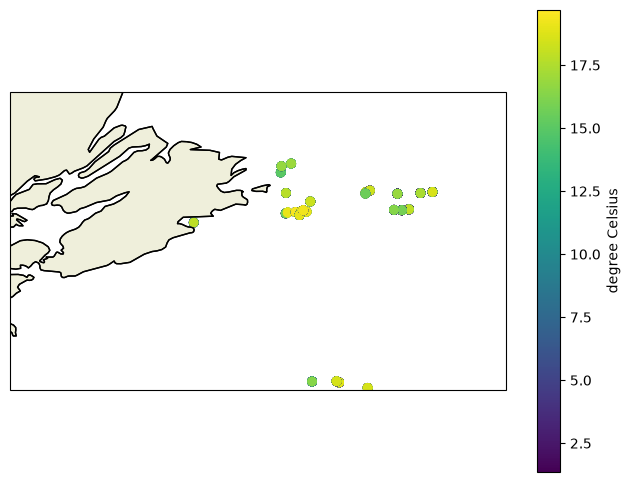

In [7]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

var = "TEMPPR01"

sc = ax.scatter(
    focc_ros["longitude"],
    focc_ros["latitude"],
    c=focc_ros[var],
    transform=ccrs.PlateCarree(),
)

ax.coastlines()
ax.add_feature(cfeature.LAND, edgecolor="black")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label=f"{focc_ros_units[var]}")
plt.ylim((45, 46.5))
plt.xlim((-61, -58.5))

(-65.0, -58.0)

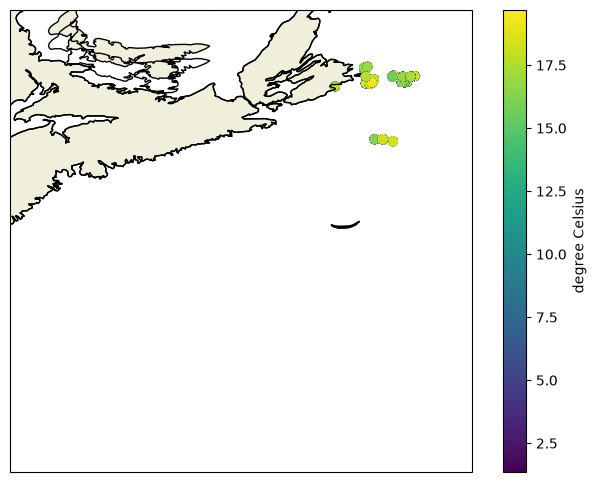

In [8]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

var = "TEMPPR01"

sc = ax.scatter(
    focc_ros["longitude"],
    focc_ros["latitude"],
    c=focc_ros[var],
    transform=ccrs.PlateCarree(),
)

ax.coastlines()
ax.add_feature(cfeature.LAND, edgecolor="black")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label=f"{focc_ros_units[var]}")
plt.ylim((40, 47))
plt.xlim((-65, -58))

...these points are in the wrong place. Gonna redownload the data.

In [26]:
focc_ros = pd.read_csv(Path("../../data/even_more_data/bio_historical_coastal_ctd_cioosatlantic_ca.csv"))
# focc_ros, focc_ros_units = focc_ros.drop(1)
focc_ros_units = focc_ros.iloc[0]
focc_ros = focc_ros.drop(0).reset_index(drop=True)
print(len(focc_ros))
print(focc_ros.head())

219
   project  platform_name  platform_id chief_scientist   cruise_name  \
0      NaN            NaN          NaN      Mike Power  Bay of Fundy   
1      NaN            NaN          NaN      Mike Power  Bay of Fundy   
2      NaN            NaN          NaN      Mike Power  Bay of Fundy   
3      NaN            NaN          NaN      Mike Power  Bay of Fundy   
4      NaN            NaN          NaN      Mike Power  Bay of Fundy   

  cruise_number  geographic_area  station                        id  \
0    VIC2009057              NaN      NaN  CTD_VIC2009057_012_13_DN   
1    VIC2009057              NaN      NaN  CTD_VIC2009057_012_13_UP   
2    VIC2009057              NaN      NaN  CTD_VIC2009057_012_13_UP   
3    VIC2009057              NaN      NaN  CTD_VIC2009057_012_13_UP   
4    VIC2009057              NaN      NaN  CTD_VIC2009057_012_13_UP   

   event_number  ... PRESPR01 PSLTZZ01 PSALST01 TEMPPR01   CNDCST01 DOXYZZ01  \
0          12.0  ...      1.0  31.8418  31.8418  10.0223

In [27]:
focc_ros["latitude"] = pd.to_numeric(focc_ros["latitude"])
focc_ros["longitude"] = pd.to_numeric(focc_ros["longitude"])
focc_ros["TEMPPR01"] = pd.to_numeric(focc_ros["TEMPPR01"])
focc_ros["depth"] = pd.to_numeric(focc_ros["depth"])    #   Normally I'd use pressure. Include that, too.
focc_ros["PRESPR01"] = pd.to_numeric(focc_ros["PRESPR01"])
focc_ros[["latitude", "longitude", "TEMPPR01", "PRESPR01", "depth"]].describe()

,latitude,longitude,TEMPPR01,PRESPR01,depth
count,219.000000,219.000000,217.000000,219.000000,219.000000
mean,44.343796,-66.181751,9.913282,19.447489,19.289602
std,0.065871,0.058524,0.140773,11.778566,11.682527
min,44.267300,-66.249700,9.720300,1.000000,0.991937
25%,44.267300,-66.249700,9.818800,10.000000,9.919149
50%,44.400000,-66.133300,9.830500,19.000000,18.845972
75%,44.400500,-66.130000,10.046200,28.000000,27.772405
max,44.400500,-66.130000,10.152200,47.000000,46.616386


(-66.5, -66.0)

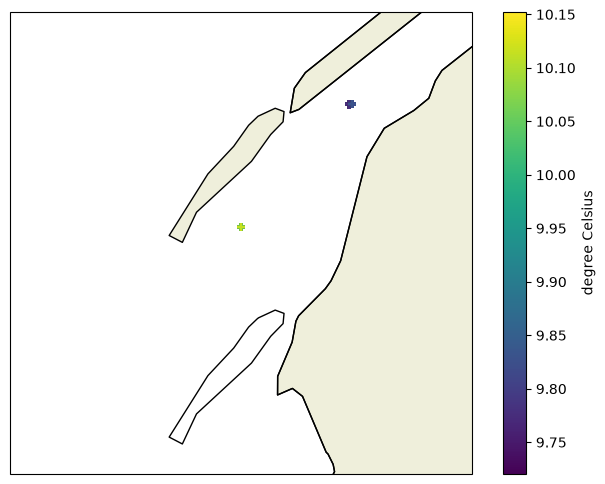

In [28]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

var = "TEMPPR01"

sc = ax.scatter(
    focc_ros["longitude"],
    focc_ros["latitude"],
    c=focc_ros[var],
    transform=ccrs.PlateCarree(),
    marker="+",
)

ax.coastlines()
ax.add_feature(cfeature.LAND, edgecolor="black")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label=f"{focc_ros_units[var]}")
plt.ylim((44, 44.5))
plt.xlim((-66.5, -66))

*This* looks right. Downloading directly through CIOOS was more reliable than through their ERDDAP link, I guess. It could also be a brain fart.

TODO: Move the data around. Get the new datasets into here, and sequester the old junk into the `aaron/` folder.

And **yeah**! Our first data points.

## FOCC moorings

In [29]:
focc_mor = pd.read_csv(Path("../../data/even_more_data/bio_historical_coastal_moored_ctd_cioosatlantic_ca.csv"))
focc_mor_units = focc_mor.iloc[0]
focc_mor = focc_mor.drop(0).reset_index(drop=True)
print(len(focc_mor))
print(focc_mor.head())

119107
                                filename         cruise_name cruise_number  \
0  MTR_94999_499_HO6525_8640.00000000.nc  mooring deployment         94999   
1  MTR_94999_499_HO6525_8640.00000000.nc  mooring deployment         94999   
2  MTR_94999_499_HO6525_8640.00000000.nc  mooring deployment         94999   
3  MTR_94999_499_HO6525_8640.00000000.nc  mooring deployment         94999   
4  MTR_94999_499_HO6525_8640.00000000.nc  mooring deployment         94999   

  chief_scientist serial_number  deployment_platform_name inst_type  \
0             NaN        HO6525                       NaN      HOBO   
1             NaN        HO6525                       NaN      HOBO   
2             NaN        HO6525                       NaN      HOBO   
3             NaN        HO6525                       NaN      HOBO   
4             NaN        HO6525                       NaN      HOBO   

                                instrument    instrument_model  \
0  HOBO,model number ,serial nu

/tmp/ipykernel_95461/2552693431.py:1: DtypeWarning: Columns (0: serial_number, 1: latitude, 2: longitude, 3: depth, 4: TEMPPR01, 5: TEMPP901, 6: SIGTEQ01, 7: POTM_01) have mixed types. Specify dtype option on import or set low_memory=False.
  focc_mor = pd.read_csv(Path("../../data/even_more_data/bio_historical_coastal_moored_ctd_cioosatlantic_ca.csv"))


In [39]:
focc_mor.columns

Index(['filename', 'cruise_name', 'cruise_number', 'chief_scientist',
       'serial_number', 'deployment_platform_name', 'inst_type', 'instrument',
       'instrument_model', 'instrument_offbottom_depth', 'mooring_number',
       'program', 'project', 'sdn_instrument_id', 'station', 'latitude',
       'longitude', 'time', 'depth', 'PRESPR01', 'PSLTZZ01', 'TEMPPR01',
       'TEMPP901', 'SIGTEQ01', 'POTM_01'],
      dtype='str')

In [41]:
focc_mor["latitude"] = pd.to_numeric(focc_mor["latitude"])
focc_mor["longitude"] = pd.to_numeric(focc_mor["longitude"])
focc_mor["TEMPPR01"] = pd.to_numeric(focc_mor["TEMPPR01"])
focc_mor["depth"] = pd.to_numeric(focc_mor["depth"])    #   Normally I'd use pressure. Include that, too.
focc_mor["PRESPR01"] = pd.to_numeric(focc_mor["PRESPR01"])
focc_mor["instrument_offbottom_depth"] = pd.to_numeric(focc_mor["instrument_offbottom_depth"])
focc_mor[["latitude", "longitude", "TEMPPR01", "PRESPR01", "depth", "instrument_offbottom_depth"]].describe()

,latitude,longitude,TEMPPR01,PRESPR01,depth,instrument_offbottom_depth
count,119107.000000,119107.000000,119107.000000,0.0,0.0,119107.000000
mean,44.443053,-66.072359,14.712065,NaN,NaN,0.245447
std,0.101441,0.083911,2.200491,NaN,NaN,2.088591
min,44.200000,-66.182000,-1.159000,NaN,NaN,0.000000
25%,44.420000,-66.150000,13.260000,NaN,NaN,0.000000
50%,44.510000,-66.010000,14.710000,NaN,NaN,0.000000
75%,44.510000,-66.010000,16.190000,NaN,NaN,0.000000
max,44.540000,-65.950000,20.410000,NaN,NaN,21.400000


The moorings have pressure/depth, but they're all NaN. Might be in the metadata?

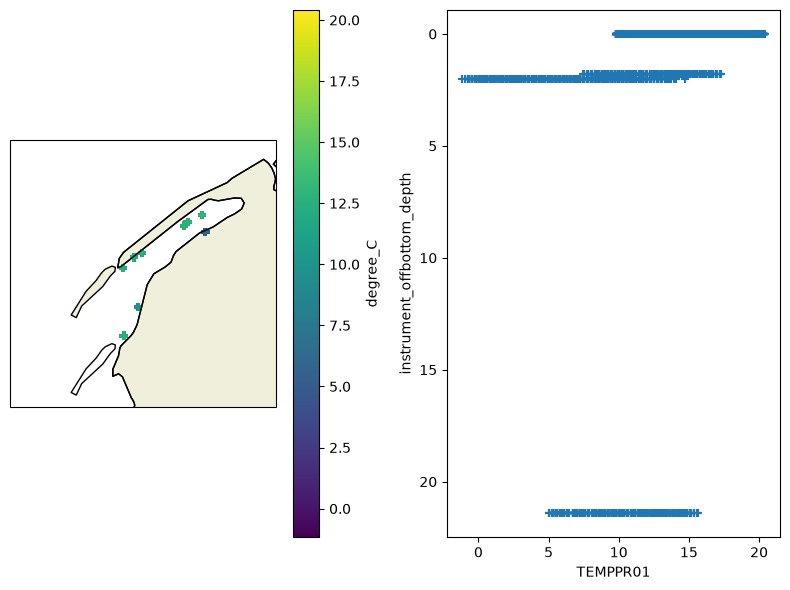

In [44]:
# fig, axs = plt.subplots(ncols=2, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
fig = plt.figure(figsize=(8, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(1, 2, 2)

var = "TEMPPR01"

sc = ax0.scatter(
    focc_mor["longitude"],
    focc_mor["latitude"],
    c=focc_mor[var],
    transform=ccrs.PlateCarree(),
    marker="+",
)

ax0.coastlines()
ax0.add_feature(cfeature.LAND, edgecolor="black")

ax0.set_xlabel("Longitude")
ax0.set_ylabel("Latitude")

ax0.set_ylim((44, 44.75))
ax0.set_xlim((-66.5, -65.75))

ax1.scatter(focc_mor[var],
    focc_mor["instrument_offbottom_depth"],
    marker="+",
)
ax1.set_ylabel("instrument_offbottom_depth")
ax1.set_xlabel(var)
ax1.invert_yaxis()

plt.colorbar(sc, ax=ax0, label=f"{focc_mor_units[var]}")
plt.tight_layout()


Good to see these moorings in different locations.